# Tarea grupal — IA en Producción — Grupo 5
## Punto 5 — Análisis de fechas

**Integrante:** _(NICOLAS BUSTOS)_
**Rama:** _(NICOLAS-BUSTOS)_



## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
ARCHIVO = 'plan_de_compras_2025.xlsx'

df = pd.read_excel(ARCHIVO, sheet_name='PLAN DE COMPRAS 2025')
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (831, 26)


,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,Cantidad Productos,Monto Unitario Ítem,Monto Total Ítem Año 2025,Cantidad OC,Meses envío OC,Nombre responsable,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,1,125000000,20000000,3,"Abr 2023,Ene 2024,Ene 2025",María Teresa Zúñiga Silva,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,1,20000000,4500000,5,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,1,15300000,3825000,4,"Oct 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,2209006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,1,18000000,4500000,6,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,2205005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,1,105600000,26400000,4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


## 5. Análisis de fechas

Se analizan `Fecha de Inicio Compra` y `Fecha Publicación PAC 2025`: rango temporal, distribución
por año/mes y el desfase entre publicación en el PAC y el inicio real de la compra.

In [3]:
print('Fecha de Inicio Compra:', df['Fecha de Inicio Compra'].min(), '→', df['Fecha de Inicio Compra'].max())
print('Fecha Publicación PAC 2025:', df['Fecha Publicación PAC 2025'].min(), '→', df['Fecha Publicación PAC 2025'].max())

df['Año Inicio Compra'] = df['Fecha de Inicio Compra'].dt.year
df['Mes Inicio Compra'] = df['Fecha de Inicio Compra'].dt.month

df['Año Inicio Compra'].value_counts().sort_index()

Fecha de Inicio Compra: 2022-02-01 00:00:00 → 2026-03-01 00:00:00
Fecha Publicación PAC 2025: 2022-11-08 00:00:00 → 2025-11-27 00:00:00


Año Inicio Compra
2022     11
2023     76
2024     96
2025    644
2026      4
Name: count, dtype: int64

In [4]:
compras_por_mes = (
    df.groupby(['Año Inicio Compra', 'Mes Inicio Compra'])
    .size()
    .rename('n_items')
    .reset_index()
)
compras_por_mes.head(15)

,Año Inicio Compra,Mes Inicio Compra,n_items
0,2022,2,1
1,2022,8,2
2,2022,11,1
3,2022,12,7
4,2023,1,9
5,2023,2,4
6,2023,3,15
7,2023,4,22
8,2023,5,4
9,2023,6,7


In [5]:
# Desfase entre la publicación en el PAC y el inicio de compra (en días)
df['Días PAC a Inicio Compra'] = (
    df['Fecha de Inicio Compra'] - df['Fecha Publicación PAC 2025']
).dt.days

df['Días PAC a Inicio Compra'].describe()

count    831.000000
mean    -243.128761
std      100.040228
min     -363.000000
25%     -330.000000
50%     -273.000000
75%     -151.000000
max       94.000000
Name: Días PAC a Inicio Compra, dtype: float64

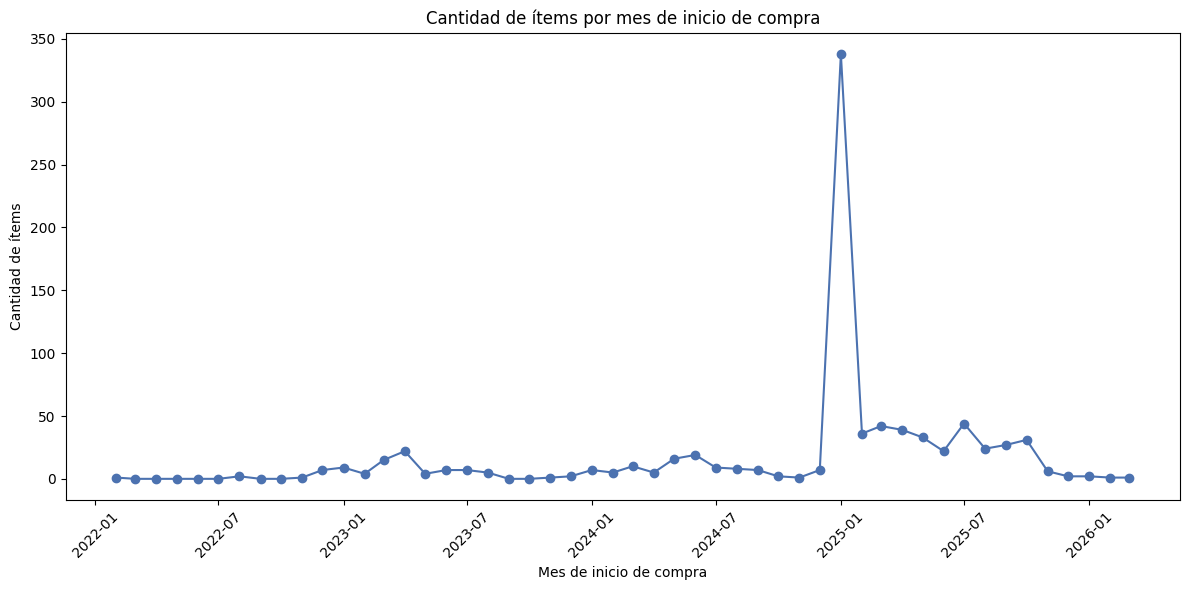

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
serie_mensual = (
    df.set_index('Fecha de Inicio Compra')
    .resample('MS')
    .size()
)
ax.plot(serie_mensual.index, serie_mensual.values, marker='o', color='#4c72b0')
ax.set_xlabel('Mes de inicio de compra')
ax.set_ylabel('Cantidad de ítems')
ax.set_title('Cantidad de ítems por mes de inicio de compra')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Resumen

- **Fechas:** compras concentradas mayoritariamente en 2025, con desfase negativo entre publicación PAC e inicio de compra (la compra suele iniciar antes de la fecha formal de publicación del PAC, lo que amerita revisión con el equipo).
